# Đánh giá mô hình Regression sử dụng Quang phổ toàn phần (Full-Spectrum: Magnitude + Phase)
Trong notebook này, chúng ta lấy 101 điểm Biên độ (Magnitude) và 101 điểm Góc pha (Phase) từ 126 file `.s2p` gốc, tạo thành ma trận 202 features để tối ưu hóa cho thuật toán XGBoost.

In [1]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import xgboost as xgb

In [2]:
def parse_s2p_file_with_phase(filepath):
    """Đọc file s2p và trả về mảng 202 điểm: 101 Magnitude (dB) + 101 Phase"""
    data = []
    with open(filepath, 'r') as f:
        for line in f:
            if line.startswith('!') or line.startswith('#'):
                continue
            parts = line.strip().split()
            if len(parts) >= 3:
                real = float(parts[1])
                imag = float(parts[2])
                # Tính Magnitude (Biên độ) dB
                mag_db = 20 * np.log10(np.sqrt(real**2 + imag**2))
                # Tính Phase (Góc pha)
                phase = np.arctan2(imag, real)
                data.extend([mag_db, phase]) # Gộp chung vào 1 mảng
    return data


### CÁCH 1: Trộn chung 2 Session và chia ngẫu nhiên (Dễ bị Data Leakage)

In [3]:
# Để áp dụng Baseline Correction (như tác giả đã dùng), ta tính trung bình các mẫu Glu0 ở mỗi Session
def load_and_correct(base_dir):
    import os, re
    import numpy as np
    
    # 1. Đọc các mẫu Glu0 (0 mg/dL - PBS) để làm Baseline
    g0_list = []
    for filename in os.listdir(base_dir):
        if filename.endswith('.s2p') and 'Glu0' in filename:
            filepath = os.path.join(base_dir, filename)
            s11_features = parse_s2p_file_with_phase(filepath)
            if len(s11_features) == 202:
                g0_list.append(s11_features)
    
    baseline = np.mean(g0_list, axis=0) if len(g0_list) > 0 else np.zeros(202)
    
    # 2. Đọc các mẫu máu (GluX) và hiệu chỉnh (Corrected)
    X_list, y_list = [], []
    for filename in os.listdir(base_dir):
        if filename.endswith('.s2p'):
            if 'Air' in filename or 'Glu0' in filename:
                continue
            match = re.search(r'Glu(\d+)', filename)
            if match:
                glucose_val = float(match.group(1))
                filepath = os.path.join(base_dir, filename)
                s11_features = parse_s2p_file_with_phase(filepath)
                if len(s11_features) == 202:
                    # HIỆU CHỈNH: Trừ đi Baseline của Session hiện tại
                    corrected = np.array(s11_features) - baseline
                    X_list.append(corrected)
                    y_list.append(glucose_val)
    return np.array(X_list), np.array(y_list)

dir_train = '/home/biu/Secure-IoMT-Embedded-Platform/dataset/Glucose_Supplementary/raw_data/session1_blood'
dir_test = '/home/biu/Secure-IoMT-Embedded-Platform/dataset/Glucose_Supplementary/raw_data/session2_blood'

# Trích xuất và Hiệu chỉnh (Baseline Corrected)
X1, y1 = load_and_correct(dir_train)
X2, y2 = load_and_correct(dir_test)

# METHOD 1: Trộn chung cả 2
X_all = np.vstack([X1, X2])
y_all = np.concatenate([y1, y2])
print(f"Đã load xong {len(X_all)} mẫu máu cho CÁCH 1 (ĐÃ HIỆU CHỈNH BASELINE).")

# CHIA TRAIN TEST NGẪU NHIÊN
from sklearn.model_selection import train_test_split
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X_all, y_all, test_size=0.2, random_state=42)


Đã load xong 132 mẫu máu cho CÁCH 1 (ĐÃ HIỆU CHỈNH BASELINE).


=== KẾT QUẢ CÁCH 1 (TRỘN CHUNG) ===
MAD (MAE): 12.3110
RMSE     : 19.9110
R2 Score : 0.9229
MARD     : 9.85%


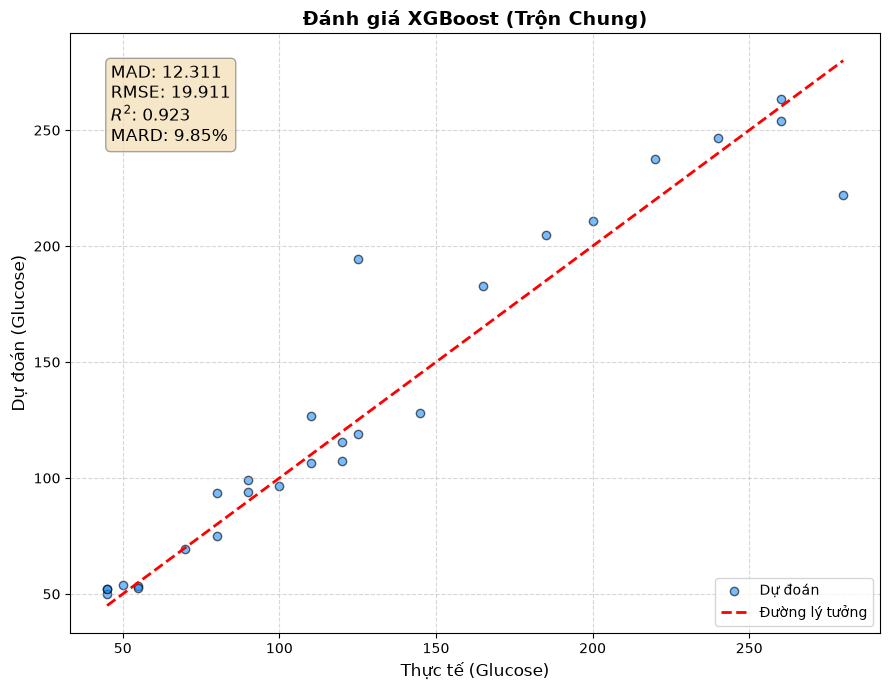

In [4]:
model_rand = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_rand.fit(X_train_rand, y_train_rand)
y_pred_rand = model_rand.predict(X_test_rand)

mad_rand = mean_absolute_error(y_test_rand, y_pred_rand)
rmse_rand = np.sqrt(mean_squared_error(y_test_rand, y_pred_rand))
r2_rand = r2_score(y_test_rand, y_pred_rand)
mard_rand = np.mean(np.abs((y_test_rand - y_pred_rand) / (y_test_rand + 1e-8))) * 100

print("=== KẾT QUẢ CÁCH 1 (TRỘN CHUNG) ===")
print(f"MAD (MAE): {mad_rand:.4f}")
print(f"RMSE     : {rmse_rand:.4f}")
print(f"R2 Score : {r2_rand:.4f}")
print(f"MARD     : {mard_rand:.2f}%")
plt.figure(figsize=(9, 7))
plt.scatter(y_test_rand, y_pred_rand, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test_rand), np.min(y_pred_rand))
max_val = max(np.max(y_test_rand), np.max(y_pred_rand))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')
textstr = '\n'.join((
    f'MAD: {mad_rand:.3f}',
    f'RMSE: {rmse_rand:.3f}',
    f'$R^2$: {r2_rand:.3f}',
    f'MARD: {mard_rand:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá XGBoost (Trộn Chung)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== KẾT QUẢ RANDOM FOREST CÁCH 1 (TRỘN CHUNG) ===
MAD (MAE): 15.7630
RMSE     : 24.9928
R2 Score : 0.8786
MARD     : 12.66%


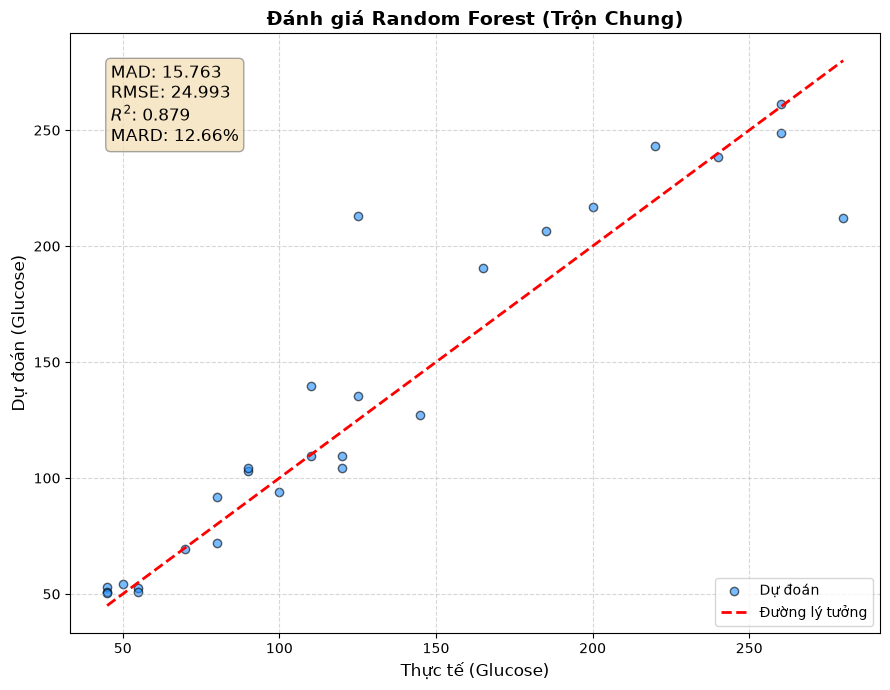

In [5]:
from sklearn.ensemble import RandomForestRegressor

model_rf_rand = RandomForestRegressor(n_estimators=300, random_state=42)
model_rf_rand.fit(X_train_rand, y_train_rand)
y_pred_rf_rand = model_rf_rand.predict(X_test_rand)

mad_rf_rand = mean_absolute_error(y_test_rand, y_pred_rf_rand)
rmse_rf_rand = np.sqrt(mean_squared_error(y_test_rand, y_pred_rf_rand))
r2_rf_rand = r2_score(y_test_rand, y_pred_rf_rand)
mard_rf_rand = np.mean(np.abs((y_test_rand - y_pred_rf_rand) / (y_test_rand + 1e-8))) * 100

print("=== KẾT QUẢ RANDOM FOREST CÁCH 1 (TRỘN CHUNG) ===")
print(f"MAD (MAE): {mad_rf_rand:.4f}")
print(f"RMSE     : {rmse_rf_rand:.4f}")
print(f"R2 Score : {r2_rf_rand:.4f}")
print(f"MARD     : {mard_rf_rand:.2f}%")
plt.figure(figsize=(9, 7))
plt.scatter(y_test_rand, y_pred_rf_rand, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test_rand), np.min(y_pred_rf_rand))
max_val = max(np.max(y_test_rand), np.max(y_pred_rf_rand))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')
textstr = '\n'.join((
    f'MAD: {mad_rf_rand:.3f}',
    f'RMSE: {rmse_rf_rand:.3f}',
    f'$R^2$: {r2_rf_rand:.3f}',
    f'MARD: {mard_rf_rand:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá Random Forest (Trộn Chung)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### CÁCH 2: Train trên Session 1, Test trên Session 2 (Thực tế - Cross Session)

In [6]:
# Tương tự như trên, nhưng đối với Cách 2 ta dùng X1, y1 cho Train và X2, y2 cho Test
X_train_cv, y_train_cv = X1, y1
X_test_cv, y_test_cv = X2, y2

print(f"Đã load xong tập Train (Session 1): {len(X_train_cv)} mẫu (ĐÃ HIỆU CHỈNH BASELINE).")
print(f"Đã load xong tập Test (Session 2): {len(X_test_cv)} mẫu (ĐÃ HIỆU CHỈNH BASELINE).")


Đã load xong tập Train (Session 1): 69 mẫu (ĐÃ HIỆU CHỈNH BASELINE).
Đã load xong tập Test (Session 2): 63 mẫu (ĐÃ HIỆU CHỈNH BASELINE).


=== KẾT QUẢ CÁCH 2 (CROSS-SESSION) ===
MAD (MAE): 50.3087
RMSE     : 57.1365
R2 Score : 0.4836
MARD     : 49.44%


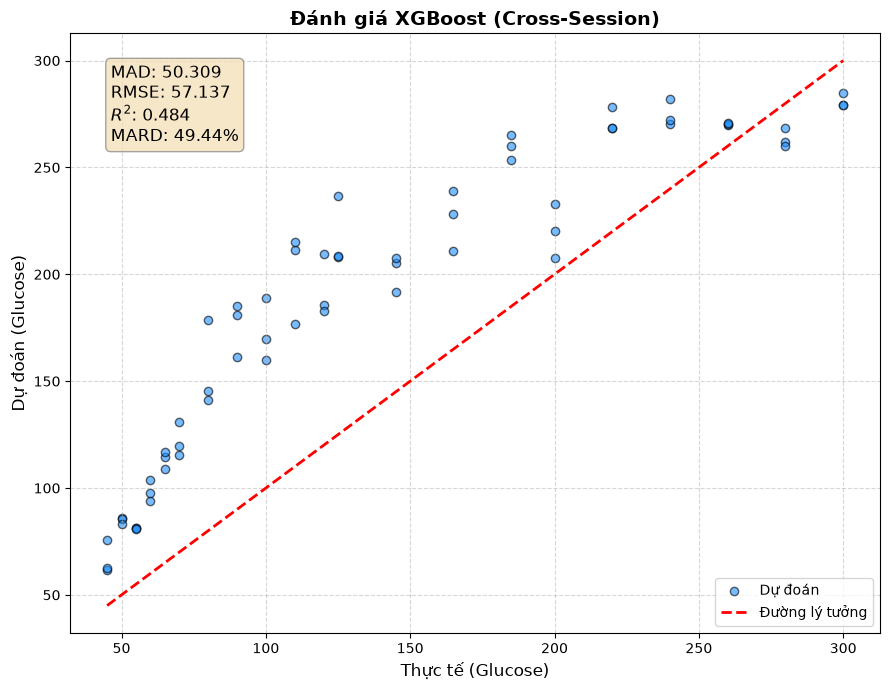

In [7]:
model_cv = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model_cv.fit(X_train_cv, y_train_cv)
y_pred_cv = model_cv.predict(X_test_cv)

mad_cv = mean_absolute_error(y_test_cv, y_pred_cv)
rmse_cv = np.sqrt(mean_squared_error(y_test_cv, y_pred_cv))
r2_cv = r2_score(y_test_cv, y_pred_cv)
mard_cv = np.mean(np.abs((y_test_cv - y_pred_cv) / (y_test_cv + 1e-8))) * 100

print("=== KẾT QUẢ CÁCH 2 (CROSS-SESSION) ===")
print(f"MAD (MAE): {mad_cv:.4f}")
print(f"RMSE     : {rmse_cv:.4f}")
print(f"R2 Score : {r2_cv:.4f}")
print(f"MARD     : {mard_cv:.2f}%")
plt.figure(figsize=(9, 7))
plt.scatter(y_test_cv, y_pred_cv, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test_cv), np.min(y_pred_cv))
max_val = max(np.max(y_test_cv), np.max(y_pred_cv))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')
textstr = '\n'.join((
    f'MAD: {mad_cv:.3f}',
    f'RMSE: {rmse_cv:.3f}',
    f'$R^2$: {r2_cv:.3f}',
    f'MARD: {mard_cv:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá XGBoost (Cross-Session)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


=== KẾT QUẢ RANDOM FOREST CÁCH 2 (CROSS-SESSION) ===
MAD (MAE): 47.9061
RMSE     : 54.4636
R2 Score : 0.5307
MARD     : 47.73%


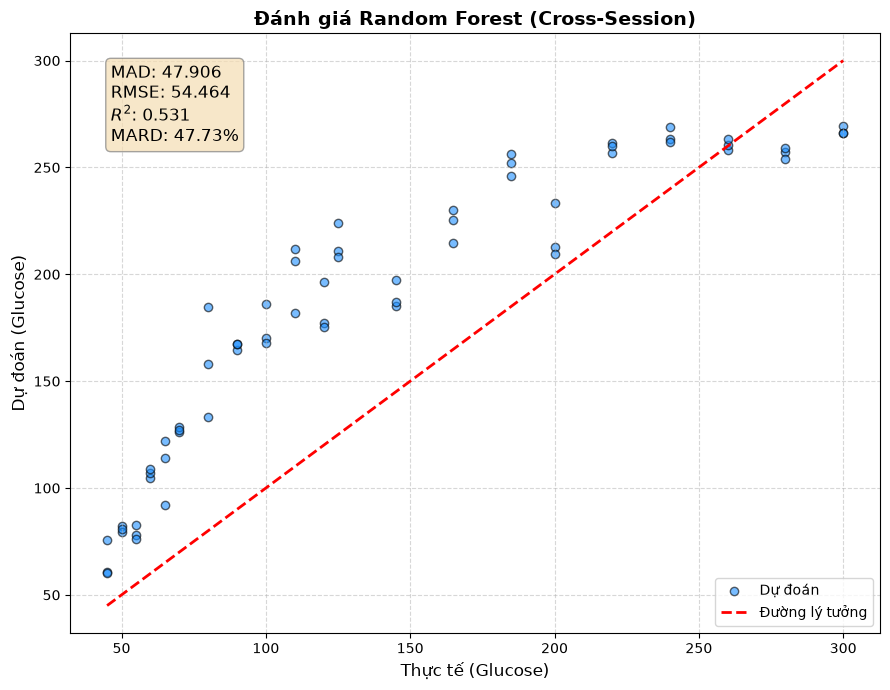

In [8]:
from sklearn.ensemble import RandomForestRegressor

model_rf_cv = RandomForestRegressor(n_estimators=300, random_state=42)
model_rf_cv.fit(X_train_cv, y_train_cv)
y_pred_rf_cv = model_rf_cv.predict(X_test_cv)

mad_rf_cv = mean_absolute_error(y_test_cv, y_pred_rf_cv)
rmse_rf_cv = np.sqrt(mean_squared_error(y_test_cv, y_pred_rf_cv))
r2_rf_cv = r2_score(y_test_cv, y_pred_rf_cv)
mard_rf_cv = np.mean(np.abs((y_test_cv - y_pred_rf_cv) / (y_test_cv + 1e-8))) * 100

print("=== KẾT QUẢ RANDOM FOREST CÁCH 2 (CROSS-SESSION) ===")
print(f"MAD (MAE): {mad_rf_cv:.4f}")
print(f"RMSE     : {rmse_rf_cv:.4f}")
print(f"R2 Score : {r2_rf_cv:.4f}")
print(f"MARD     : {mard_rf_cv:.2f}%")
plt.figure(figsize=(9, 7))
plt.scatter(y_test_cv, y_pred_rf_cv, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test_cv), np.min(y_pred_rf_cv))
max_val = max(np.max(y_test_cv), np.max(y_pred_rf_cv))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')
textstr = '\n'.join((
    f'MAD: {mad_rf_cv:.3f}',
    f'RMSE: {rmse_rf_cv:.3f}',
    f'$R^2$: {r2_rf_cv:.3f}',
    f'MARD: {mard_rf_cv:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)

plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá Random Forest (Cross-Session)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### CÁCH 3: Dùng duy nhất 1 Đặc trưng Cộng hưởng 4.3 GHz (Cách tốt nhất theo tác giả)
Tác giả chỉ ra rằng việc dùng toàn bộ quang phổ (Full Spectrum) sẽ gây Overfitting trên Session 1 và sụp đổ trên Session 2 (sai số lên tới ~44%). Giải pháp là chỉ trích xuất **độ lệch Biên độ (Magnitude) tại tần số cộng hưởng 4.3 GHz** (Index 132 trong mảng 202 features của chúng ta).

In [9]:
import numpy as np
# Trích xuất đúng index của 4.3 GHz Magnitude
# Tần số quét từ 1 GHz - 6 GHz (101 điểm), bước nhảy 50MHz.
# 4.3 GHz nằm ở điểm thứ 67 (index 66 của mảng 101 điểm).
# Vì mảng 202 điểm của ta lưu xen kẽ [Mag, Phase, Mag, Phase...], nên Mag của 4.3 GHz nằm ở index 66 * 2 = 132.

X_train_cv_43 = X_train_cv[:, [132]]
X_test_cv_43 = X_test_cv[:, [132]]
print(f"Kích thước tập Train: {X_train_cv_43.shape}")
print(f"Kích thước tập Test: {X_test_cv_43.shape}")


Kích thước tập Train: (69, 1)
Kích thước tập Test: (63, 1)


=== KẾT QUẢ XGBOOST (CHỈ DÙNG 4.3 GHZ - CROSS SESSION) ===
MAD (MAE): 25.3172
RMSE     : 36.7726
R2 Score : 0.7861
MARD     : 20.04%


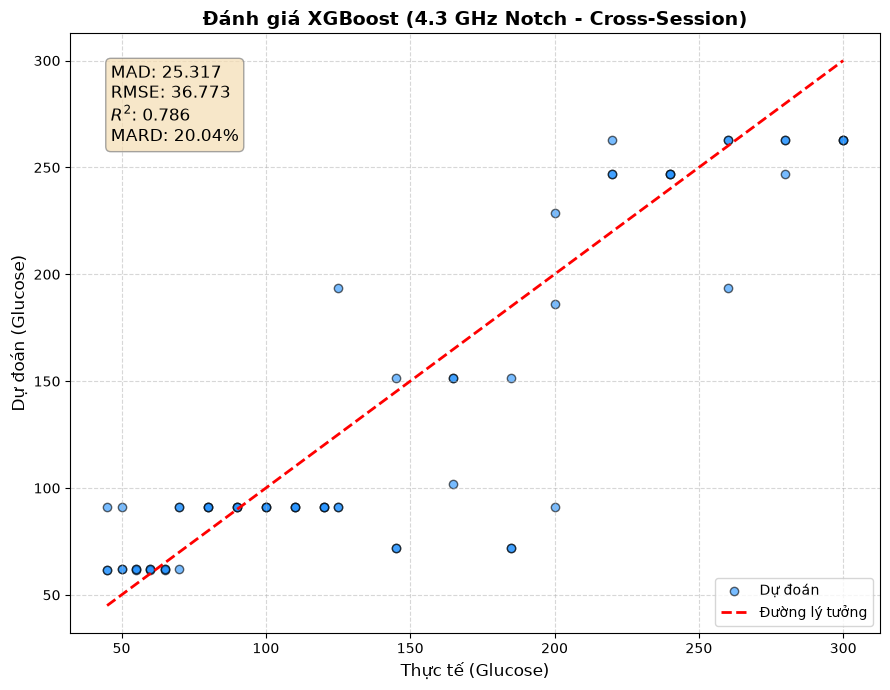

In [ ]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import matplotlib.pyplot as plt

model_xgb_43 = xgb.XGBRegressor(n_estimators=300, learning_rate=0.01, max_depth=3, random_state=42)
model_xgb_43.fit(X_train_cv_43, y_train_cv)
y_pred_xgb_43 = model_xgb_43.predict(X_test_cv_43)

mad_xgb_43 = mean_absolute_error(y_test_cv, y_pred_xgb_43)
rmse_xgb_43 = np.sqrt(mean_squared_error(y_test_cv, y_pred_xgb_43))
r2_xgb_43 = r2_score(y_test_cv, y_pred_xgb_43)
mard_xgb_43 = np.mean(np.abs((y_test_cv - y_pred_xgb_43) / (y_test_cv + 1e-8))) * 100

print("=== KẾT QUẢ XGBOOST (CHỈ DÙNG 4.3 GHZ - CROSS SESSION) ===")
print(f"MAD (MAE): {mad_xgb_43:.4f}")
print(f"RMSE     : {rmse_xgb_43:.4f}")
print(f"R2 Score : {r2_xgb_43:.4f}")
print(f"MARD     : {mard_xgb_43:.2f}%")

plt.figure(figsize=(9, 7))
plt.scatter(y_test_cv, y_pred_xgb_43, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test_cv), np.min(y_pred_xgb_43))
max_val = max(np.max(y_test_cv), np.max(y_pred_xgb_43))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')
textstr = '\n'.join((
    f'MAD: {mad_xgb_43:.3f}',
    f'RMSE: {rmse_xgb_43:.3f}',
    f'$R^2$: {r2_xgb_43:.3f}',
    f'MARD: {mard_xgb_43:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá XGBoost (4.3 GHz Notch - Cross-Session)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

=== KẾT QUẢ RANDOM FOREST (CHỈ DÙNG 4.3 GHZ - CROSS SESSION) ===
MAD (MAE): 25.2891
RMSE     : 38.7970
R2 Score : 0.7619
MARD     : 20.06%


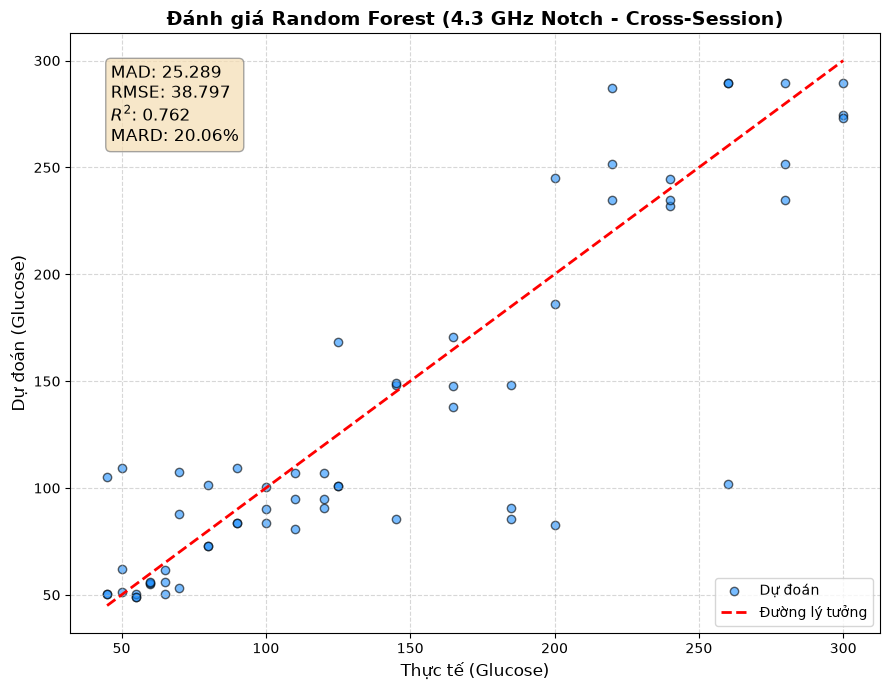

In [ ]:
from sklearn.ensemble import RandomForestRegressor

model_rf_43 = RandomForestRegressor(n_estimators=300, random_state=42)
model_rf_43.fit(X_train_cv_43, y_train_cv)
y_pred_rf_43 = model_rf_43.predict(X_test_cv_43)

mad_rf_43 = mean_absolute_error(y_test_cv, y_pred_rf_43)
rmse_rf_43 = np.sqrt(mean_squared_error(y_test_cv, y_pred_rf_43))
r2_rf_43 = r2_score(y_test_cv, y_pred_rf_43)
mard_rf_43 = np.mean(np.abs((y_test_cv - y_pred_rf_43) / (y_test_cv + 1e-8))) * 100

print("=== KẾT QUẢ RANDOM FOREST (CHỈ DÙNG 4.3 GHZ - CROSS SESSION) ===")
print(f"MAD (MAE): {mad_rf_43:.4f}")
print(f"RMSE     : {rmse_rf_43:.4f}")
print(f"R2 Score : {r2_rf_43:.4f}")
print(f"MARD     : {mard_rf_43:.2f}%")

plt.figure(figsize=(9, 7))
plt.scatter(y_test_cv, y_pred_rf_43, alpha=0.6, color='dodgerblue', edgecolor='k', label='Dự đoán')
min_val = min(np.min(y_test_cv), np.min(y_pred_rf_43))
max_val = max(np.max(y_test_cv), np.max(y_pred_rf_43))
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--', linewidth=2, label='Đường lý tưởng')
textstr = '\n'.join((
    f'MAD: {mad_rf_43:.3f}',
    f'RMSE: {rmse_rf_43:.3f}',
    f'$R^2$: {r2_rf_43:.3f}',
    f'MARD: {mard_rf_43:.2f}%'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.7, edgecolor='gray')
plt.gca().text(0.05, 0.95, textstr, transform=plt.gca().transAxes, fontsize=12,
        verticalalignment='top', bbox=props)
plt.xlabel("Thực tế (Glucose)", fontsize=12)
plt.ylabel("Dự đoán (Glucose)", fontsize=12)
plt.title("Đánh giá Random Forest (4.3 GHz Notch - Cross-Session)", fontsize=14, fontweight='bold')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()